# Stage 2 — Fine-tune RuModernBERT cross-encoder + temperature scaling

**Goal:** fine-tune `deepvk/RuModernBERT-base` as cross-encoder `[CLS] query [SEP] org_text [SEP]`, evaluate on val, calibrate probabilities, save predictions.

**Environment:** Google Colab (T4 GPU), `fp16=True` recommended.

**Output artifacts:**
- `models/bert/best_checkpoint/`
- `models/bert/training_args.json`
- `models/bert/calibration.json` — temperature scaling (T)
- `predictions/bert_val_preds.parquet` — `bert_pred`, `bert_proba1` (calibrated), `bert_correct`
- `predictions/bert_ood_preds.parquet`
- `reports/stage2_bert/metrics.json`
- `reports/stage2_bert/reliability_before_scaling.png`
- `reports/stage2_bert/reliability_after_scaling.png`

**Expected metrics:** val accuracy ~0.74–0.80, macro-F1 ~0.73–0.79 (argmax unchanged after calibration)

## 0. Colab Only — Install & Drive


## 1. Dependencies & Paths

In [ ]:
IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r",
     "/content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/requirements.txt"],
    check=True
)
print("Done")

Done


In [ ]:
pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.5 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import random
import sys
import warnings
from pathlib import Path
import numpy as np
import torch
import json
import pandas as pd
from transformers import set_seed


warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('/content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance')
sys.path.insert(0, str(PROJECT_ROOT))

from utils.config import (
    TARGET,
    PROCESSED_DATA_DIR,
    BERT_BEST_CHECKPOINT_DIR,
    BERT_MODEL_NAME,
    BERT_MAX_LENGTH,
    RANDOM_STATE,
    STAGE2_RELIABILITY_BEFORE_PATH,
    STAGE2_RELIABILITY_AFTER_PATH,
)
from utils.stage2_bert import (
    run_stage2,
    load_stage2_splits,
    validate_train_data,
    build_tokenizer,
    log_token_length_stats,
)

from utils.config import COL_QUERY, COL_ORG_TEXT
from transformers import AutoTokenizer

print('Model:', BERT_MODEL_NAME, '| max_length:', BERT_MAX_LENGTH)

print('Project root:', PROJECT_ROOT)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

Model: deepvk/RuModernBERT-base | max_length: 1024
Project root: /content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance
CUDA available: True
GPU: Tesla T4


## 2. Load Data

In [ ]:
train_df, val_df, ood_df = load_stage2_splits(PROCESSED_DATA_DIR)
validate_train_data(train_df)

tokenizer = build_tokenizer()
log_token_length_stats(train_df, tokenizer)
print(f'Train: {len(train_df)}, Val: {len(val_df)}, OOD: {len(ood_df)}')
print(f'Label distribution train:\n{train_df[TARGET].value_counts()}')

config.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/21.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

Train: 21270, Val: 4558, OOD: 4703
Label distribution train:
label
1    11118
0    10152
Name: count, dtype: int64


In [ ]:
train_df.head()

,permalink,text,name,address,normalized_main_rubric_name_ru,label,relevance,reviews_summarized,prices_summarized,org_text
0,1097486280,рено,Автофранция; Avtofrantsiya; Автоф; Автоклиника...,"Санкт-Петербург, Складская улица, 6","Автосервис , автотехцентр",0,0.0,Организация занимается обслуживанием и ремонто...,Автофранция предоставляет услуги по ремонту и ...,Автофранция; Avtofrantsiya; Автоф; Автоклиника...
1,42521410080,169460 индекс,Оксфорд; Oxford,"Санкт-Петербург, Дальневосточный проспект, 12,...",Курсы иностранных языков,0,0.0,Организация «Оксфорд» занимается обучением ино...,Организация предлагает образовательные курсы д...,"Оксфорд; Oxford | Санкт-Петербург, Дальневосто..."
2,219167386536,лучшие итальянские рестораны в москве,Osteria Mario,"Москва, Мичуринский проспект, 3",Ресторан,1,1.0,Организация занимается предоставлением рестора...,Osteria Mario предлагает широкий выбор итальян...,"Osteria Mario | Москва, Мичуринский проспект, ..."
3,147029257063,листовой шифер плоский цена,ОАО Белгородасбестоцемент; БелАЦИ; Белгородасб...,"Белгород, улица Мичурина, 104",ЖБИ,1,1.0,Организация занимается производством и продаже...,No pricelist.,ОАО Белгородасбестоцемент; БелАЦИ; Белгородасб...
4,1127982752,Лодочные моторв,Профиснасть; Profisnast; Профи снасть,"Санкт-Петербург, улица Крупской, 38Б",Водная техника,0,0.0,Организация «Профиснасть» занимается продажей ...,Компания «Профиснасть» предлагает товары для в...,Профиснасть; Profisnast; Профи снасть | Санкт-...


In [ ]:
tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
# --- замер по всем строкам (не семплируем — хотим точный максимум) ---
def token_lengths(df: pd.DataFrame) -> np.ndarray:
    return np.array([
        len(tokenizer(q, o, add_special_tokens=True)['input_ids'])
        for q, o in zip(df[COL_QUERY], df['org_text'])
    ])

stats = {}
for name, df in [('train', train_df), ('val', val_df), ('ood', ood_df)]:
    lens = token_lengths(df)
    stats[name] = lens
    print(f"{name:6s}  n={len(lens):>6}  "
          f"p50={np.percentile(lens,50):>4.0f}  "
          f"p90={np.percentile(lens,90):>4.0f}  "
          f"p95={np.percentile(lens,95):>4.0f}  "
          f"p99={np.percentile(lens,99):>4.0f}  "
          f"max={lens.max():>4}")

# --- сколько примеров обрежется при разных MAX_LENGTH ---
print()
for max_len in [512, 1024, 2048, 4096]:
    for name, lens in stats.items():
        cut = (lens > max_len).mean()
        if cut > 0:
            print(f"MAX_LENGTH={max_len:>5}  {name:6s}  обрежется {cut:.1%}")

train   n= 21270  p50= 545  p90= 722  p95= 767  p99= 868  max=1810
val     n=  4558  p50= 542  p90= 721  p95= 766  p99= 851  max=1714
ood     n=  4703  p50= 535  p90= 717  p95= 766  p99= 872  max=1685

MAX_LENGTH=  512  train   обрежется 57.6%
MAX_LENGTH=  512  val     обрежется 57.0%
MAX_LENGTH=  512  ood     обрежется 55.3%
MAX_LENGTH= 1024  train   обрежется 0.1%
MAX_LENGTH= 1024  val     обрежется 0.1%
MAX_LENGTH= 1024  ood     обрежется 0.1%


В config.py прописана константа BERT_MAX_LENGTH  = 1024.

## 3. Training + calibration

Cross-encoder tokenization (`truncation='only_second'`) → Trainer (5 epochs, batch 16) → temperature scaling → predictions.

In [ ]:
# Full pipeline: train → checkpoint → temperature scaling → val/OOD parquet.
# If OOM on T4: per_device_train_batch_size=8 and gradient_accumulation in TrainingArguments.
summary = run_stage2(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    auto_resume=False
)

print(f"\n=== Stage 2 complete ===")
print(f"Val Accuracy:  {summary['val_accuracy']:.4f}")
print(f"Val Macro-F1:  {summary['val_macro_f1']:.4f}")
print(f"Checkpoint:    {summary['checkpoint_dir']}")
if summary.get("temperature") is not None:
    print(
        f"T = {summary['temperature']:.4f}  "
        f"NLL {summary['nll_before']:.4f} → {summary['nll_after']:.4f}  "
        f"ECE {summary['ece_before']:.4f} → {summary['ece_after']:.4f}"
    )

Map:   0%|          | 0/21270 [00:00<?, ? examples/s]

Map:   0%|          | 0/4558 [00:00<?, ? examples/s]

Map:   0%|          | 0/4703 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.556709,0.505037,0.768978,0.768319
2,0.446910,0.548832,0.768539,0.768051


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Stage 2 complete ===
Val Accuracy:  0.7690
Val Macro-F1:  0.7683
Checkpoint:    /content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/models/bert/best_checkpoint
T = 1.1091  NLL 0.5050 → 0.4967  ECE 0.0564 → 0.0389


In [ ]:
summary

{'val_accuracy': 0.7689776217639316,
 'val_macro_f1': 0.7683191243230276,
 'checkpoint_dir': '/content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/models/bert/best_checkpoint',
 'val_preds_path': '/content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/predictions/bert_val_preds.parquet',
 'ood_preds_path': '/content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/predictions/bert_ood_preds.parquet',
 'metrics_path': '/content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/reports/stage2_bert/metrics.json',
 'train_rows': 21270,
 'val_rows': 4558,
 'ood_rows': 4703,
 'calibration_path': '/content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/models/bert/calibration.json',
 'temperature': 1.1091078519821167,
 'nll_before': 0.5050347785530807,
 'nll_after': 0.4967448600880622,
 'ece_before': 0.05639140981569486,
 'ece_after': 0.03894895329391449,
 'reliability_before_path': '/content/drive/MyDrive/Colab_Notebooks/NLP_ODS

## 3.5 Reliability diagrams

Temperature scaling уже выполнен в `run_stage2()`. Ниже — калибровочные метрики и диаграммы до/после scaling.

T = 1.1091
NLL: 0.5050 → 0.4967
ECE: 0.0564 → 0.0389
Saved: /content/drive/MyDrive/Colab_Notebooks/NLP_ODS_2026/yandex_relevance/models/bert/calibration.json

До temperature scaling:


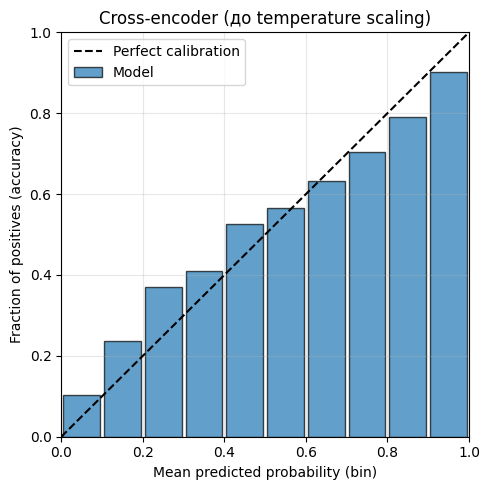

После temperature scaling:


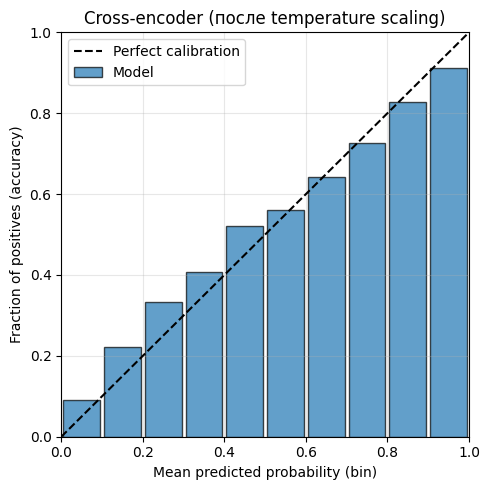

In [ ]:
from IPython.display import Image, display

from utils.config import BERT_CALIBRATION_PATH

with open(BERT_CALIBRATION_PATH, encoding="utf-8") as f:
    cal = json.load(f)

print(f"T = {cal['temperature']:.4f}")
print(f"NLL: {cal['nll_before']:.4f} → {cal['nll_after']:.4f}")
print(f"ECE: {cal['ece_before']:.4f} → {cal['ece_after']:.4f}")
print(f"Saved: {BERT_CALIBRATION_PATH}")

print("\nДо temperature scaling:")
display(Image(filename=STAGE2_RELIABILITY_BEFORE_PATH))
print("После temperature scaling:")
display(Image(filename=STAGE2_RELIABILITY_AFTER_PATH))

## 4. Artifact Check

In [ ]:
import json
import pandas as pd
from pathlib import Path

from utils.config import (
    BERT_VAL_PREDS_PATH,
    BERT_OOD_PREDS_PATH,
    BERT_BEST_CHECKPOINT_DIR,
    BERT_CALIBRATION_PATH,
    BERT_TRAINING_ARGS_PATH,
    STAGE2_REPORTS_DIR,
)

# --- Val predictions ---
val_preds = pd.read_parquet(BERT_VAL_PREDS_PATH)
print(f"bert_val_preds  shape : {val_preds.shape}")
print(f"bert_val_preds  cols  : {list(val_preds.columns)}")
print(f"val accuracy          : {val_preds['bert_correct'].mean():.4f}")
display(val_preds.head(3))

# --- OOD predictions ---
ood_preds = pd.read_parquet(BERT_OOD_PREDS_PATH)
print(f"bert_ood_preds  shape : {ood_preds.shape}")
print(f"bert_ood_preds  cols  : {list(ood_preds.columns)}")
print(f"OOD pred distribution :\n{ood_preds['bert_pred'].value_counts()}")
print(f"bert_proba1 median    : {ood_preds['bert_proba1'].median():.3f}")
display(ood_preds.head(3))

# --- Calibration ---
with open(BERT_CALIBRATION_PATH, encoding="utf-8") as f:
    cal = json.load(f)
print(f"\nCalibration  T={cal['temperature']:.4f}  "
      f"NLL {cal['nll_before']:.4f}→{cal['nll_after']:.4f}  "
      f"ECE {cal['ece_before']:.4f}→{cal['ece_after']:.4f}")

# --- Metrics report ---
with open(Path(STAGE2_REPORTS_DIR) / 'metrics.json', encoding='utf-8') as f:
    metrics = json.load(f)
print(f"\nVal accuracy (report) : {metrics['val_accuracy']:.4f}")
print(f"Val macro-F1 (report) : {metrics['val_macro_f1']:.4f}")

# --- Training meta ---
with open(BERT_TRAINING_ARGS_PATH, encoding='utf-8') as f:
    training_meta = json.load(f)
print(f"\nTraining meta: {training_meta}")

# --- Checkpoint ---
ckpt = Path(BERT_BEST_CHECKPOINT_DIR)
print(f"\nCheckpoint exists : {ckpt.exists()}")
if ckpt.exists():
    print(f"Checkpoint files  : {[f.name for f in sorted(ckpt.iterdir())]}")


bert_val_preds  shape : (4558, 13)
bert_val_preds  cols  : ['permalink', 'text', 'name', 'address', 'normalized_main_rubric_name_ru', 'label', 'relevance', 'reviews_summarized', 'prices_summarized', 'org_text', 'bert_pred', 'bert_proba1', 'bert_correct']
val accuracy          : 0.7690


,permalink,text,name,address,normalized_main_rubric_name_ru,label,relevance,reviews_summarized,prices_summarized,org_text,bert_pred,bert_proba1,bert_correct
0,1159793608,ремонт электроинструмента воронеж,Эвис-Моторс центр; Evis-Motors Central; Evis-M...,"Москва, Партийный переулок, 1к58с1","Автосервис , автотехцентр",0,0.0,"Организация занимается автообслуживанием, вклю...",Эвис-Моторс центр предлагает широкий спектр ус...,Эвис-Моторс центр; Evis-Motors Central; Evis-M...,0,0.040868,True
1,144249356742,городской пляж,Заводской пляж,"Республика Дагестан, Избербаш, квартал Головна...",Пляж,1,1.0,Организация занимается обслуживанием пляжа в г...,No pricelist.,"Заводской пляж | Республика Дагестан, Избербаш...",1,0.733952,True
2,174444886423,Спортивная школа,МБУ СП Спортивная школа № 1; Спортивная школа ...,"Алтайский край, Рубцовск, проспект Ленина, 171А",Спортивная школа,1,1.0,Организация занимается дополнительным спортивн...,No pricelist.,МБУ СП Спортивная школа № 1; Спортивная школа ...,1,0.900499,True


bert_ood_preds  shape : (4703, 12)
bert_ood_preds  cols  : ['permalink', 'text', 'name', 'address', 'normalized_main_rubric_name_ru', 'label', 'relevance', 'reviews_summarized', 'prices_summarized', 'org_text', 'bert_pred', 'bert_proba1']
OOD pred distribution :
bert_pred
1    2509
0    2194
Name: count, dtype: int64
bert_proba1 median    : 0.543


,permalink,text,name,address,normalized_main_rubric_name_ru,label,relevance,reviews_summarized,prices_summarized,org_text,bert_pred,bert_proba1
0,201938477844,спортзал где 1 занятие бесплатно,Унца Унца Спорт; Unza Unza Sport,"Москва, Страстной бульвар, 13А",Фитнес-клуб,0,0.1,Организация «Унца Унца Спорт» предоставляет ус...,Фитнес-клуб предлагает пробные занятия по разл...,"Унца Унца Спорт; Unza Unza Sport | Москва, Стр...",0,0.288536
1,45560155729,вегетарианские кафе в москве,Горыныч; Gorynych; Gorynich; Ресторан Горыныч,"Москва, Рождественский бульвар, 1",Ресторан,0,0.1,"Организация «Горыныч» — это ресторан в Москве,...",Ресторан «Горыныч» предлагает разнообразные бл...,Горыныч; Gorynych; Gorynich; Ресторан Горыныч ...,0,0.042253
2,30894893511,Лом черных и цветных металлов,Пункт приёма лома чёрных и цветных металлов; П...,"Пермь, улица Лянгасова, 139/1",Приём и скупка вторсырья,0,0.1,Организация занимается приёмом и скупкой лома ...,No pricelist.,Пункт приёма лома чёрных и цветных металлов; П...,1,0.890301



Calibration  T=1.1091  NLL 0.5050→0.4967  ECE 0.0564→0.0389

Val accuracy (report) : 0.7690
Val macro-F1 (report) : 0.7683

Training meta: {'base_model': 'deepvk/RuModernBERT-base', 'architecture': 'cross-encoder: [CLS] text [SEP] org_text [SEP]', 'org_text_cols': 'name | address | normalized_main_rubric_name_ru | reviews_summarized | prices_summarized', 'truncation': 'only_second', 'max_length': 1024, 'epochs': 5, 'batch_size': 8, 'lr': 2e-05, 'early_stopping_patience': 1, 'random_state': 42, 'best_val_acc': 0.7689776217639316, 'last_macro_f1': 0.7680511514670565, 'calibration': 'temperature scaling — see calibration.json'}

Checkpoint exists : True
Checkpoint files  : ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


## Stage 2 Summary

| Artifact | Path |
|---|---|
| Checkpoint | `models/bert/best_checkpoint/` |
| Training args | `models/bert/training_args.json` |
| Calibration | `models/bert/calibration.json` |
| Val predictions | `predictions/bert_val_preds.parquet` |
| OOD predictions | `predictions/bert_ood_preds.parquet` |
| Metrics | `reports/stage2_bert/metrics.json` |
| Reliability (до scaling) | `reports/stage2_bert/reliability_before_scaling.png` |
| Reliability (после scaling) | `reports/stage2_bert/reliability_after_scaling.png` |

**Next step:** `notebooks/stage3_error_analysis.ipynb` — error analysis, taxonomy, confidence threshold.

| Column | Description |
|---|---|
| `bert_pred` | Predicted label {0, 1} — argmax of logits (unchanged by T scaling) |
| `bert_proba1` | P(class=1) **after** temperature scaling — для Stage 3/4/5 |
| `bert_correct` | val only: `bert_pred == label` |

#### Comparison with Stage 1

| Модель | Val accuracy | Val macro-F1 |
|---|---|---|
| Stage 1 — TF-IDF + LR |  0.6367   | 0.6366 |
| Stage 2 — RuModernBERT CE | 0.7690 | 0.7683|
| Ожидание по ТЗ v9 | 0.74–0.80 | 0.73–0.79 |